In [1]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Markdown, display

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "REMAKE" / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from REMAKE.data.share_data import load_share_data
from REMAKE.scripts.mpc import plot_mpc_outputs, run_admm_mpc, run_local_mpc
from REMAKE.utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/20260504_193738_6ac06409")
cfg, run_dir = load_experiment_context(run_dir)
share_data = load_share_data(run_dir / "share_data", cfg)
display(Markdown("# REMAKE MPC"))
display(pd.DataFrame([{"run_dir": str(run_dir), "eval_start": cfg.data.eval_start_date, "eval_end": cfg.data.eval_end_date, "eval_episodes": int(share_data.eval["price"].shape[0])}]))


# REMAKE MPC

,run_dir,eval_start,eval_end,eval_episodes
0,artifacts\runs\20260504_193738_6ac06409,2020-04-01,2020-04-15,15


In [3]:
local_records = run_local_mpc(cfg, run_dir, share_data)
admm_record = run_admm_mpc(cfg, run_dir, share_data)
records = {"local": local_records, "admm": admm_record}
metrics_df = pd.concat([local_records["perfect"]["metrics_df"], local_records["lstm"]["metrics_df"], admm_record["metrics_df"]], ignore_index=True)
display(Markdown("## Metrics"))
display(metrics_df)
pprint({"record_root": str(run_dir / "results")})


local MPC modes:   0%|          | 0/2 [00:00<?, ?mode/s]

Local MPC + Perfect Forecast/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2685996


...

Local MPC + LSTM Forecast/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

ADMM MPC + LSTM Forecast/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

## Metrics

,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Local MPC + Perfect Forecast,continuous,900.239625,1476.654497,576.414872,-576.414872,0.0,-576.414875,7.804380,7.654746e-05,...,0.019089,0.065087,0.005663,0.039240,157,170.051788,33.020977,312.749985,44.195540,-576.414875
1,Local MPC + LSTM Forecast,continuous,438.391753,710.146723,271.754970,-271.754970,0.0,-271.754970,3.772795,6.608673e-04,...,0.014083,0.046186,0.004943,0.039214,116,170.433380,26.356198,232.583805,28.378163,-271.754970
2,ADMM MPC + LSTM Forecast,continuous,415.308859,643.182932,227.874073,-227.874073,0.0,-227.874072,6.917124,2.742144e-08,...,0.011000,0.049437,0.004490,0.039606,0,97.748772,21.956781,123.547836,26.525425,-227.874072


{'record_root': 'artifacts\\runs\\20260504_193738_6ac06409\\results'}

D:\GithubProject\MADRL_ESS\REMAKE\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


1. 电力电量平衡

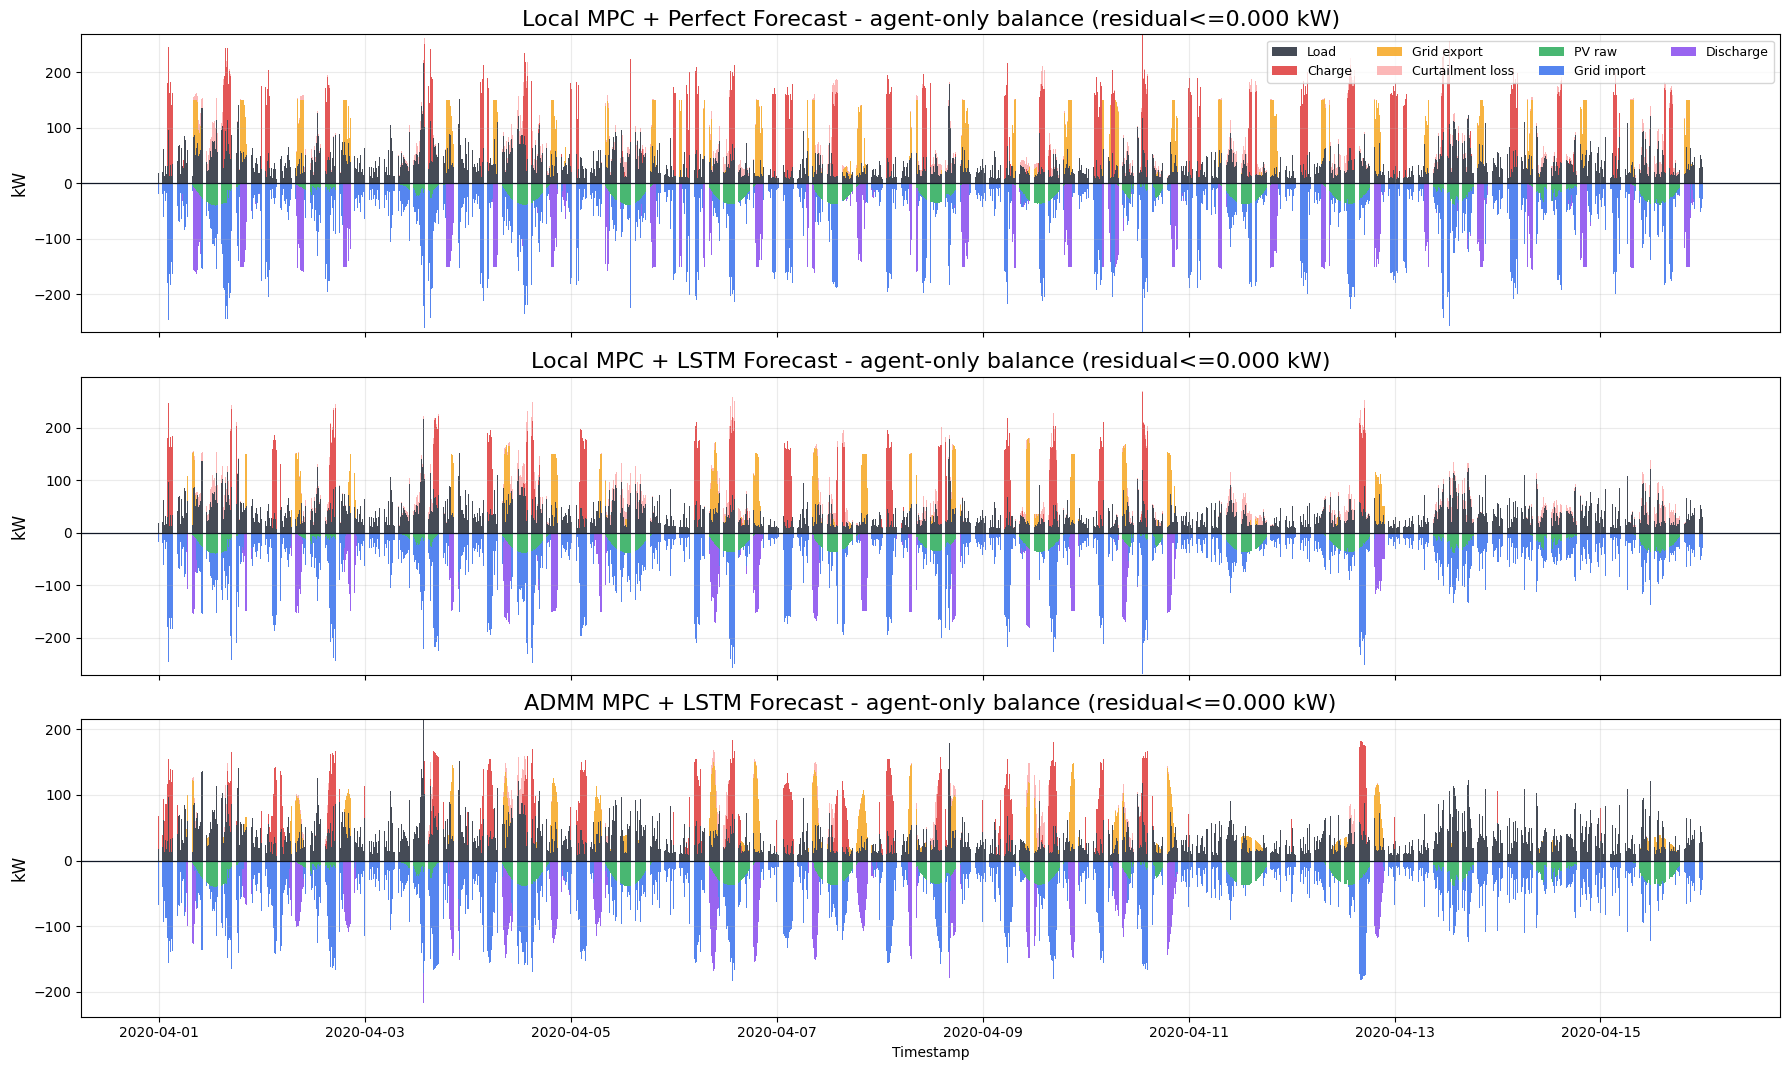

2. 电价

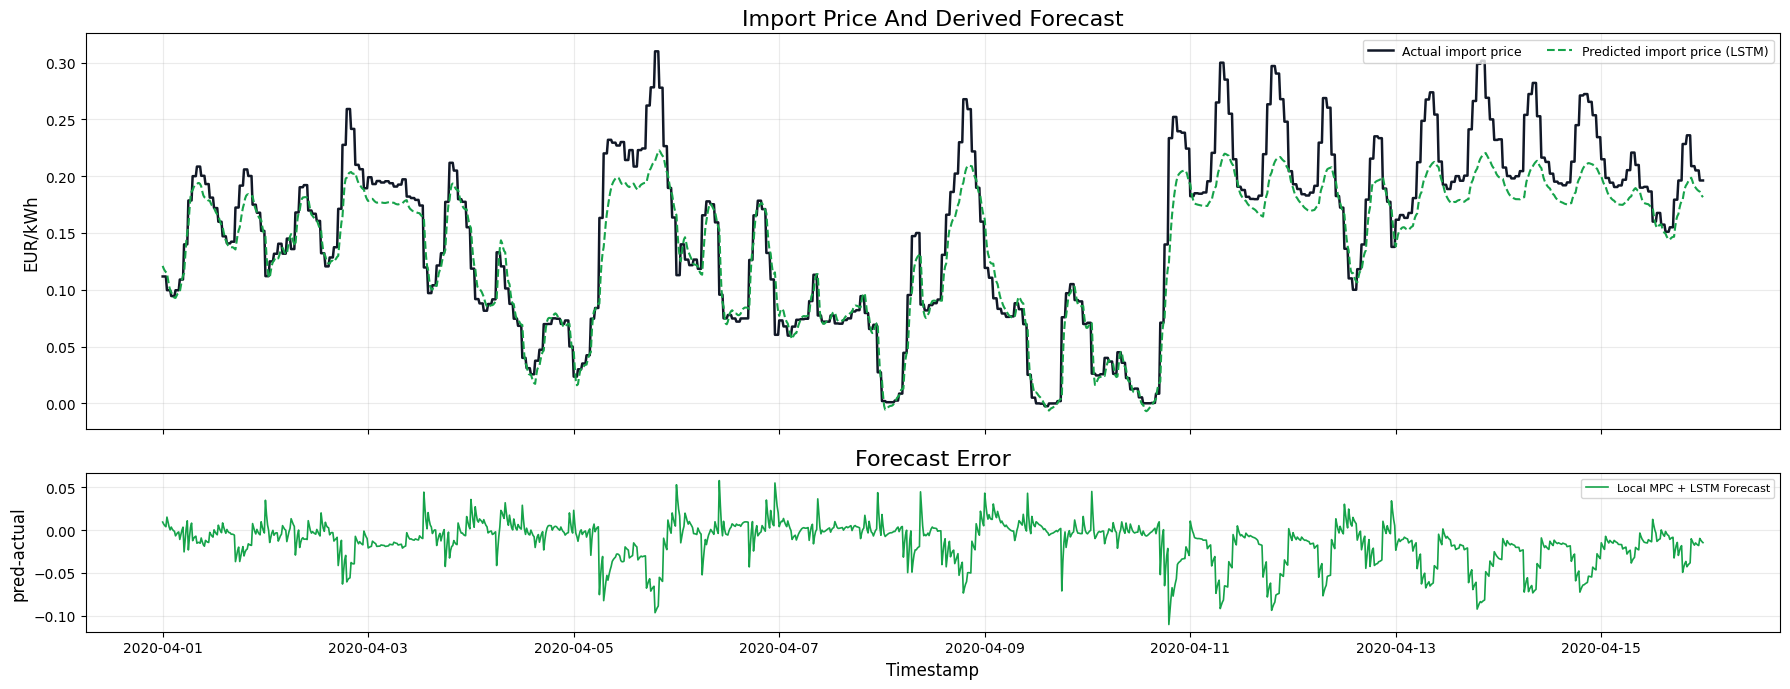

3. 总体储能充放功率与 SoC

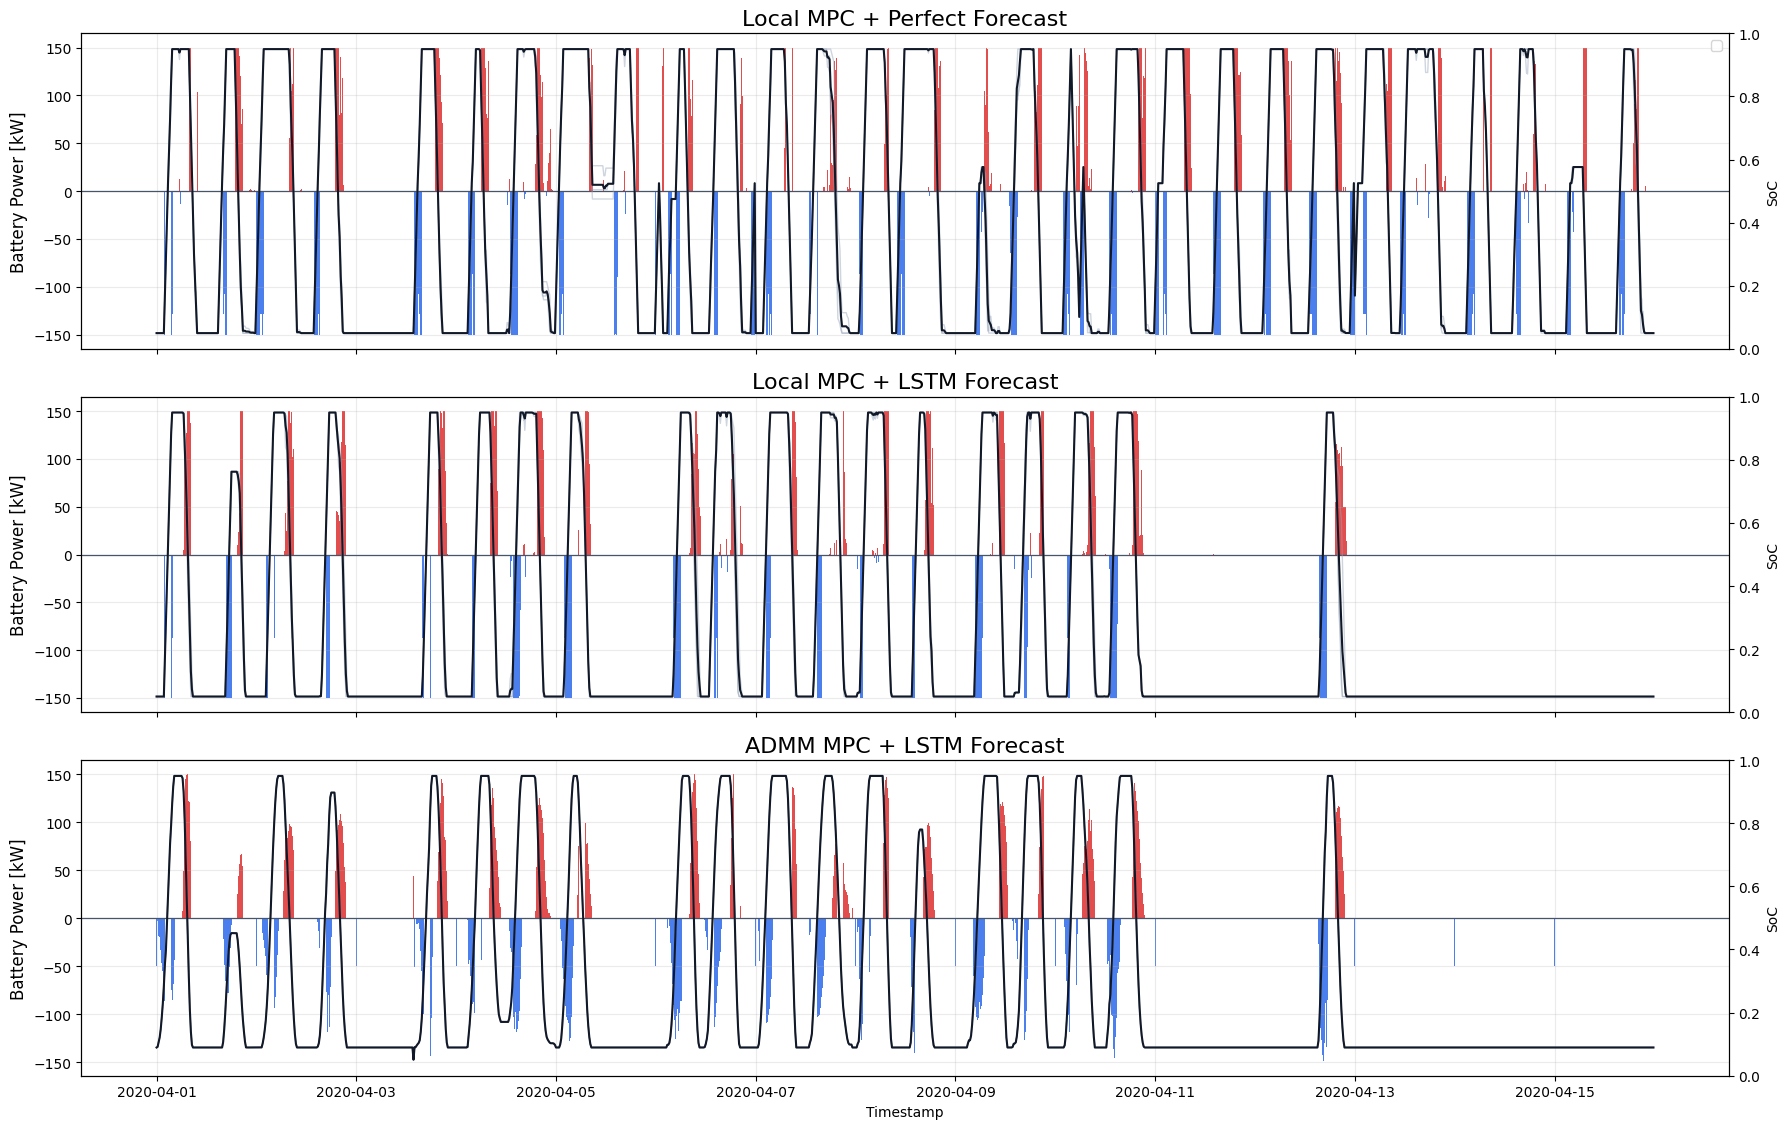

4. 电压

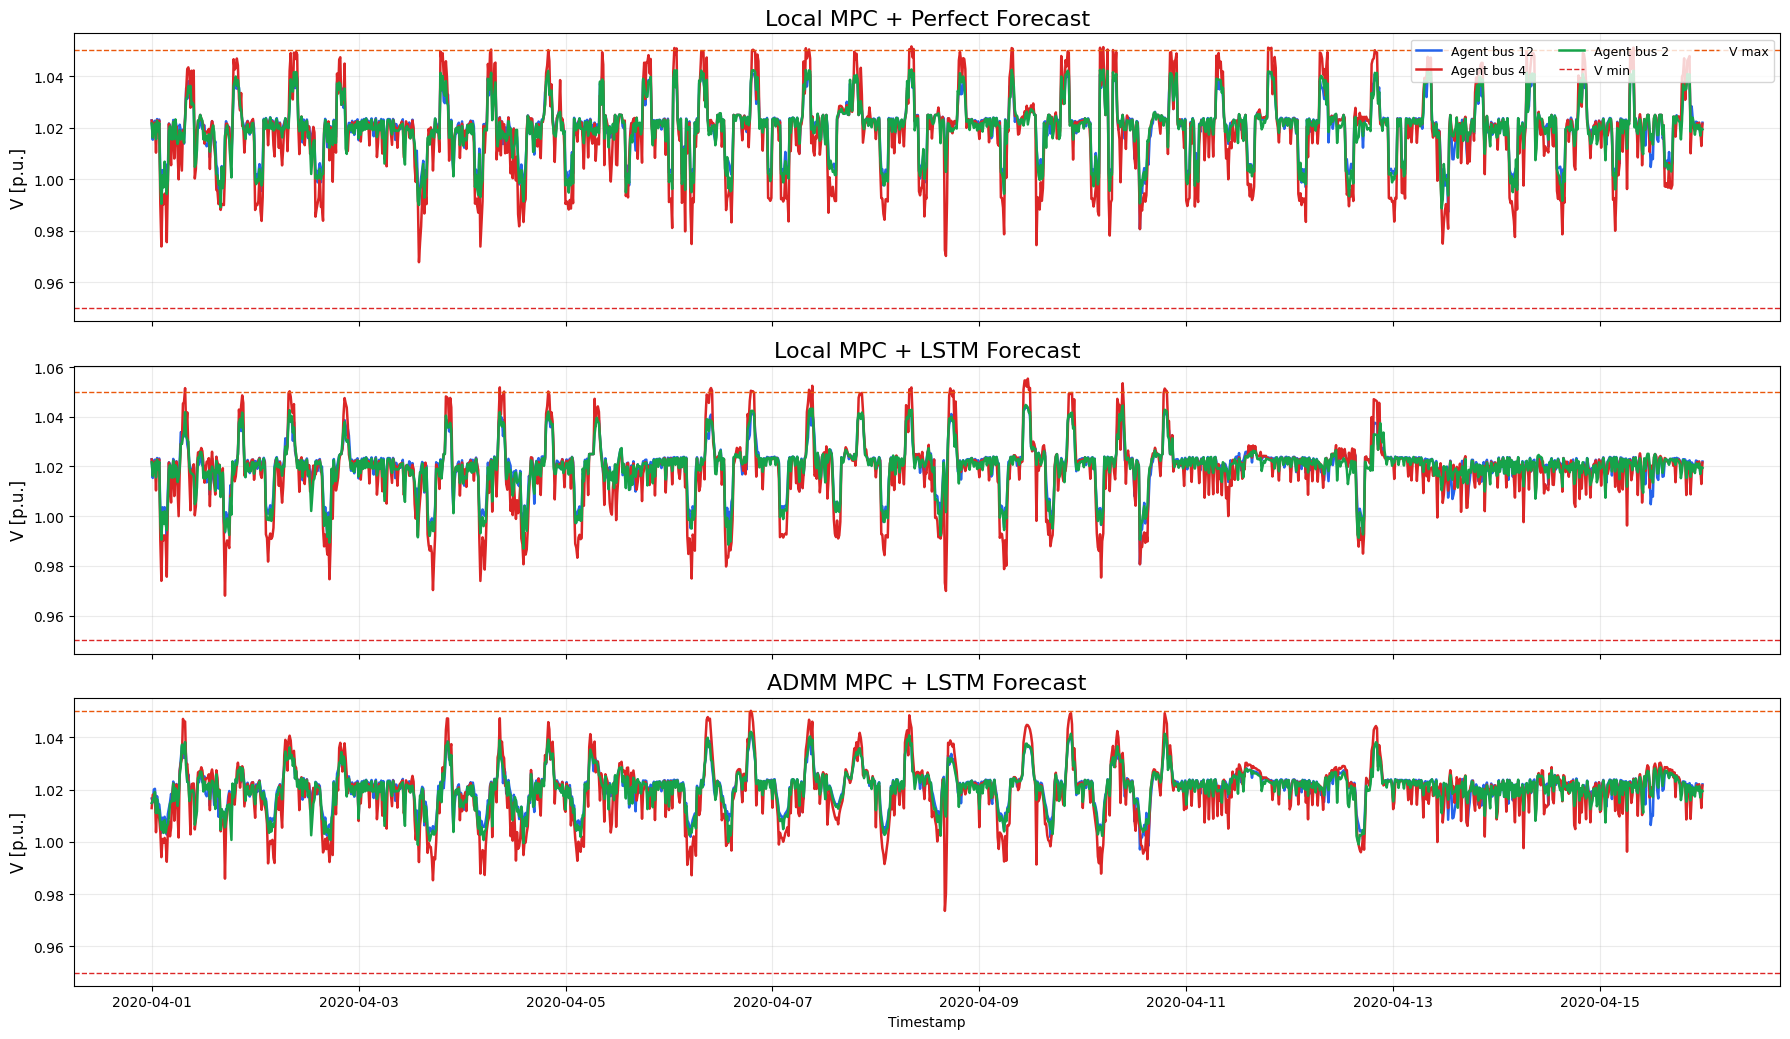

5. 净负荷

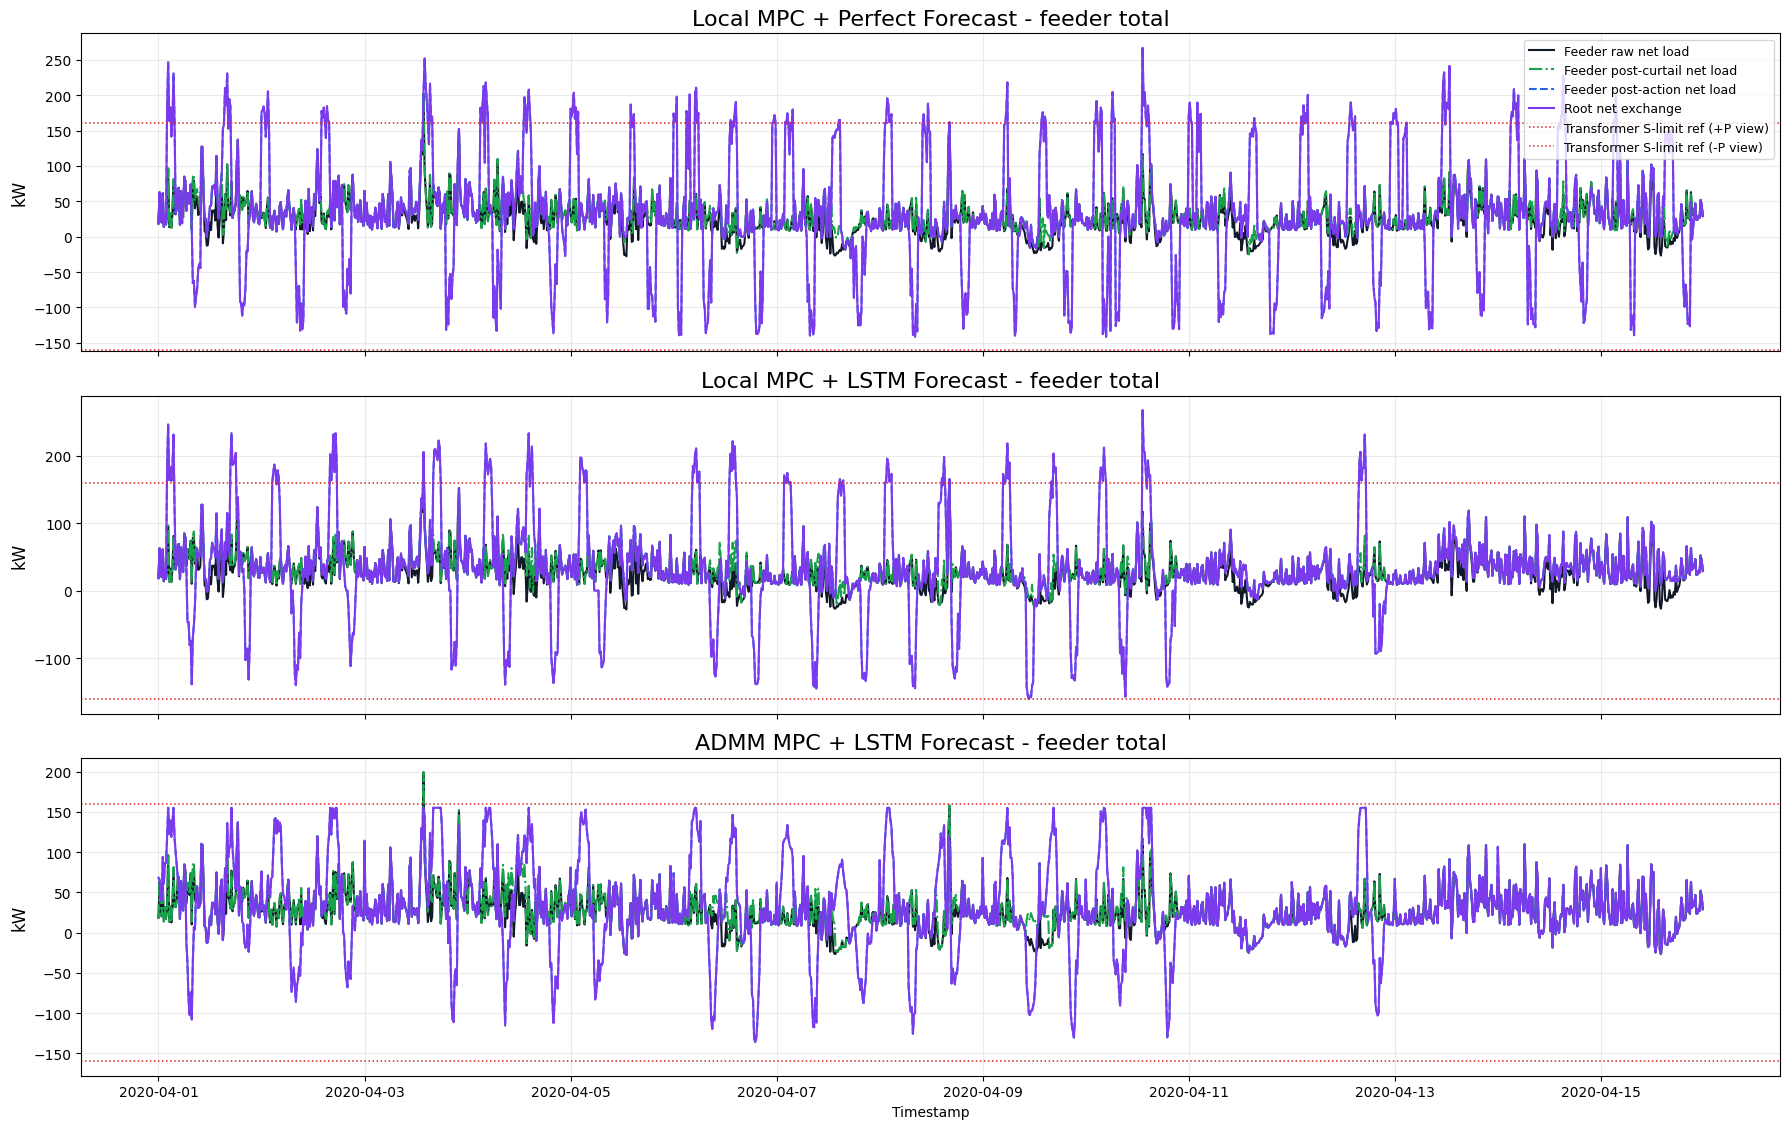

In [4]:
figures = plot_mpc_outputs(records, run_dir)
_plot_specs = [
    ("1. 电力电量平衡", "mpc_power_balance"),
    ("2. 电价", "mpc_price"),
    ("3. 总体储能充放功率与 SoC", "mpc_battery_soc"),
    ("4. 电压", "mpc_voltage"),
    ("5. 净负荷", "mpc_net_load"),
]
for title, name in _plot_specs:
    print(title)
    display(figures[name])
    plt.close(figures[name])
